In [ ]:
import pandas as pd
# Load CSV
df = pd.read_csv('../multi-model/dataset/val/val.csv')
# /home/aj-000/python_projects/m/02/backup/multi-model/dataset/val/val.csv

In [7]:
# Remove 'images/' prefix from image_path column
df['image_path'] = df['image_path'].str.replace('images/', '', regex=False)

In [ ]:
# Save back to CSV
df.to_csv('../multi-model/dataset/val/val.csv', index=False)
print("Done! 'images/' prefix removed from image_path column")

Done! 'images/' prefix removed from image_path column


In [1]:
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv('../multi-model/dataset/train/train.csv')

# Check if stuck attributes correlate with learnable ones
stuck = ['attention_score', 'predicted_ctr', 'likelihood_shares']
learnable = ['theme', 'sentiment', 'emotion', 'dominant_colour']

print("=== Cross-tabulation: Does attention_score correlate with theme? ===")
for s in stuck:
    for l in learnable:
        ct = pd.crosstab(df[s], df[l])
        chi2, p, dof, _ = chi2_contingency(ct)
        print(f"{s} vs {l}: chi2={chi2:.2f}, p={p:.4f} {'CORRELATED' if p < 0.05 else 'INDEPENDENT'}")

=== Cross-tabulation: Does attention_score correlate with theme? ===
attention_score vs theme: chi2=0.00, p=1.0000 INDEPENDENT
attention_score vs sentiment: chi2=6.25, p=0.1811 INDEPENDENT
attention_score vs emotion: chi2=12.22, p=0.1415 INDEPENDENT
attention_score vs dominant_colour: chi2=18.56, p=0.1823 INDEPENDENT
predicted_ctr vs theme: chi2=0.00, p=1.0000 INDEPENDENT
predicted_ctr vs sentiment: chi2=1.00, p=0.9092 INDEPENDENT
predicted_ctr vs emotion: chi2=6.87, p=0.5505 INDEPENDENT
predicted_ctr vs dominant_colour: chi2=20.89, p=0.1044 INDEPENDENT
likelihood_shares vs theme: chi2=0.00, p=1.0000 INDEPENDENT
likelihood_shares vs sentiment: chi2=6.39, p=0.1721 INDEPENDENT
likelihood_shares vs emotion: chi2=5.66, p=0.6853 INDEPENDENT
likelihood_shares vs dominant_colour: chi2=3.78, p=0.9967 INDEPENDENT


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

SECTION 1: CLASS DISTRIBUTION PER ATTRIBUTE

theme (9 classes):
  Entropy ratio: 1.0000  ⚠️  PERFECTLY UNIFORM (SYNTHETIC)
  Food           :   360 (11.1%) ████
  Fashion        :   360 (11.1%) ████
  Tech           :   360 (11.1%) ████
  Automotive     :   360 (11.1%) ████
  Travel         :   360 (11.1%) ████
  Finance        :   360 (11.1%) ████
  Home           :   360 (11.1%) ████
  Gaming         :   360 (11.1%) ████
  Education      :   360 (11.1%) ████

sentiment (3 classes):
  Entropy ratio: 0.9668  ✅ Natural variation
  Positive       :  1488 (45.9%) ██████████████████
  Negative       :   960 (29.6%) ███████████
  Neutral        :   792 (24.4%) █████████

emotion (5 classes):
  Entropy ratio: 0.9886  ✅ Natural variation
  Trust          :   888 (27.4%) ██████████
  Excitement     :   672 (20.7%) ████████
  Joy            :   576 (17.8%) ███████
  Anger          :   552 (17.0%) ██████
  Fear           :   552 (17.0%) ██████

dominant_colour (10 classes):
  Entropy ratio: 0.96

Text(0.5, 1.0, 'p-value Matrix\n<0.05=correlated (green) | 1.0=synthetic (red)')

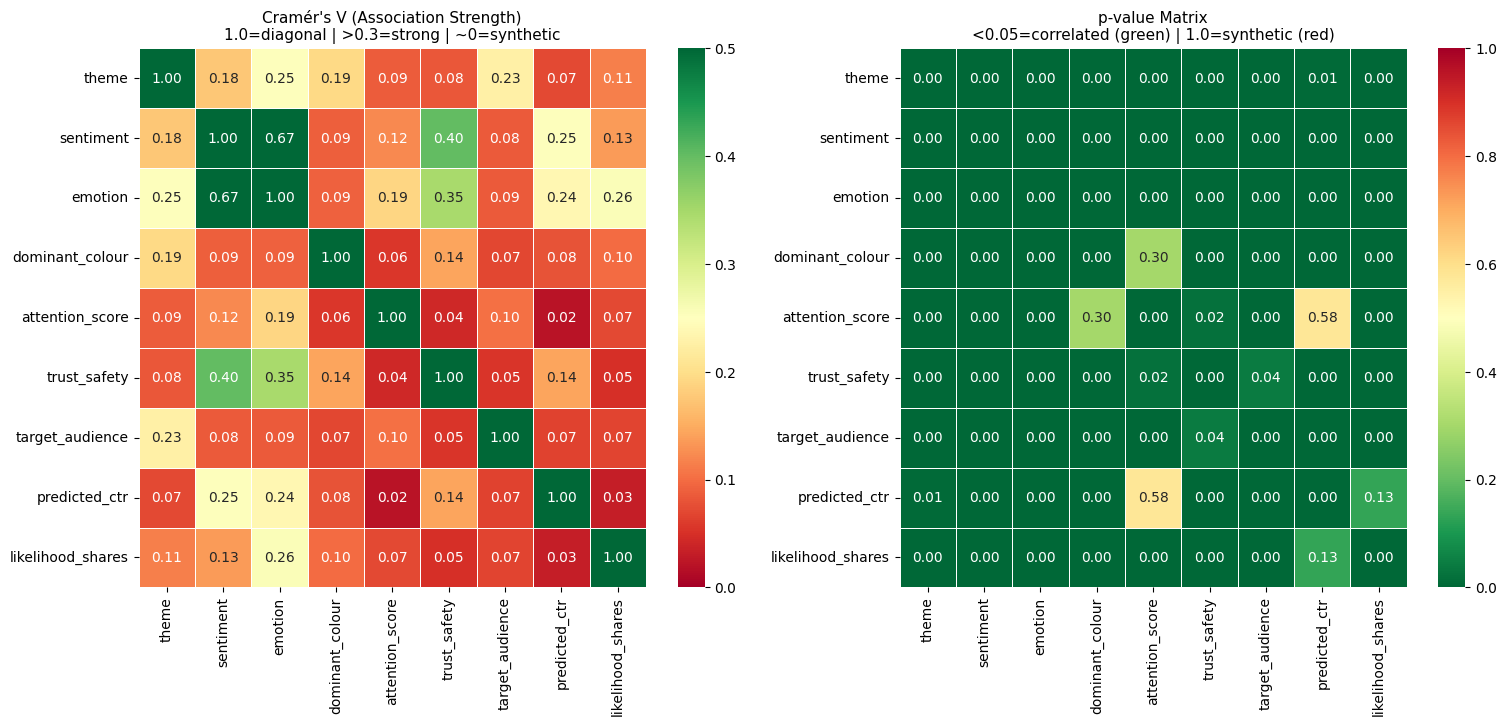

In [3]:


df = pd.read_csv('../multi-model/dataset/02.csv')

# Define all label columns
label_cols = ['theme', 'sentiment', 'emotion', 'dominant_colour', 
              'attention_score', 'trust_safety', 'target_audience', 
              'predicted_ctr', 'likelihood_shares']

# ============================================================
# 1. BASIC DISTRIBUTION CHECK
# ============================================================
print("=" * 60)
print("SECTION 1: CLASS DISTRIBUTION PER ATTRIBUTE")
print("=" * 60)

for col in label_cols:
    counts = df[col].value_counts()
    total = len(df)
    entropy_max = np.log(len(counts))  # max possible entropy
    probs = counts / total
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    entropy_ratio = entropy / entropy_max  # 1.0 = perfectly uniform = suspicious

    print(f"\n{col} ({len(counts)} classes):")
    print(f"  Entropy ratio: {entropy_ratio:.4f}  "
          f"{'⚠️  PERFECTLY UNIFORM (SYNTHETIC)' if entropy_ratio > 0.999 else '✅ Natural variation'}")
    for label, count in counts.items():
        bar = "█" * int(count / total * 40)
        print(f"  {str(label):15s}: {count:5d} ({count/total*100:.1f}%) {bar}")

# ============================================================
# 2. PAIRWISE CHI-SQUARE MATRIX
# ============================================================
print("\n" + "=" * 60)
print("SECTION 2: PAIRWISE CHI-SQUARE CORRELATION MATRIX")
print("=" * 60)
print("p < 0.05  = CORRELATED   (good - real signal)")
print("p >= 0.05 = INDEPENDENT  (could be synthetic)")
print("p = 1.000 = PERFECTLY INDEPENDENT (definitely synthetic)\n")

pairs = list(combinations(label_cols, 2))
chi2_matrix = pd.DataFrame(np.nan, index=label_cols, columns=label_cols)
pval_matrix = pd.DataFrame(np.nan, index=label_cols, columns=label_cols)
cramersv_matrix = pd.DataFrame(np.nan, index=label_cols, columns=label_cols)

results = []

for col1, col2 in pairs:
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    # Cramér's V — normalized effect size [0,1]
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    chi2_matrix.loc[col1, col2] = chi2
    chi2_matrix.loc[col2, col1] = chi2
    pval_matrix.loc[col1, col2] = p
    pval_matrix.loc[col2, col1] = p
    cramersv_matrix.loc[col1, col2] = cramers_v
    cramersv_matrix.loc[col2, col1] = cramers_v

    flag = ""
    if p == 1.0:
        flag = "🚨 PERFECTLY INDEPENDENT (SYNTHETIC)"
    elif p > 0.05:
        flag = "⚠️  INDEPENDENT"
    elif cramers_v > 0.3:
        flag = "✅ STRONGLY CORRELATED"
    else:
        flag = "✅ CORRELATED"

    results.append({
        'col1': col1, 'col2': col2,
        'chi2': round(chi2, 2),
        'p_value': round(p, 4),
        'cramers_v': round(cramers_v, 4),
        'dof': dof,
        'flag': flag
    })
    print(f"  {col1:20s} vs {col2:20s} | "
          f"chi2={chi2:8.2f} | p={p:.4f} | V={cramers_v:.3f} | {flag}")

# ============================================================
# 3. SUMMARY SCORE PER ATTRIBUTE
# ============================================================
print("\n" + "=" * 60)
print("SECTION 3: PER-ATTRIBUTE QUALITY SCORE")
print("=" * 60)
print("Score = % of other attributes it is correlated with (p<0.05)")
print("High score = real signal | Low score = likely synthetic\n")

attr_scores = {}
for col in label_cols:
    related = [r for r in results if r['col1'] == col or r['col2'] == col]
    correlated = [r for r in related if r['p_value'] < 0.05]
    score = len(correlated) / len(related) * 100
    avg_v = np.mean([r['cramers_v'] for r in related])
    attr_scores[col] = score
    
    bar = "█" * int(score / 10)
    status = "✅ REAL SIGNAL" if score > 30 else "⚠️  WEAK" if score > 0 else "🚨 SYNTHETIC"
    print(f"  {col:20s}: {score:5.1f}% correlated | avg Cramér's V={avg_v:.3f} | {status}")

# ============================================================
# 4. OVERALL DATASET QUALITY SCORE
# ============================================================
print("\n" + "=" * 60)
print("SECTION 4: OVERALL DATASET QUALITY SUMMARY")
print("=" * 60)

synthetic_attrs = [col for col, score in attr_scores.items() if score == 0]
weak_attrs      = [col for col, score in attr_scores.items() if 0 < score <= 30]
real_attrs      = [col for col, score in attr_scores.items() if score > 30]

total_pairs = len(results)
correlated_pairs = len([r for r in results if r['p_value'] < 0.05])
synthetic_pairs  = len([r for r in results if r['p_value'] == 1.0])

overall_score = correlated_pairs / total_pairs * 100

print(f"\n  Total attribute pairs    : {total_pairs}")
print(f"  Correlated pairs (p<0.05): {correlated_pairs}  ({correlated_pairs/total_pairs*100:.1f}%)")
print(f"  Synthetic pairs (p=1.000): {synthetic_pairs}  ({synthetic_pairs/total_pairs*100:.1f}%)")
print(f"\n  ✅ Real signal attributes  ({len(real_attrs)}): {real_attrs}")
print(f"  ⚠️  Weak attributes         ({len(weak_attrs)}): {weak_attrs}")
print(f"  🚨 Synthetic attributes    ({len(synthetic_attrs)}): {synthetic_attrs}")
print(f"\n  📊 OVERALL DATASET QUALITY SCORE: {overall_score:.1f} / 100")

if overall_score >= 70:
    print("  → GOOD dataset. Most labels have real signal.")
elif overall_score >= 40:
    print("  → MODERATE dataset. Some labels are learnable.")
else:
    print("  → POOR dataset. Many labels are synthetic/random.")

# ============================================================
# 5. CROSS-TAB UNIFORMITY CHECK
# ============================================================
print("\n" + "=" * 60)
print("SECTION 5: CROSS-TAB UNIFORMITY CHECK")
print("(Checks if every cell = exactly N/classes → round-robin)")
print("=" * 60)

for col in label_cols:
    ct = pd.crosstab(df['theme'], df[col])
    is_uniform = ct.apply(lambda x: x.nunique() == 1).all()
    std_dev = ct.values.std()
    print(f"  {col:20s}: std={std_dev:6.2f} "
          f"{'🚨 ROUND-ROBIN ASSIGNED' if std_dev < 0.01 else '✅ Natural'}")

# ============================================================
# 6. HEATMAP VISUALISATION
# ============================================================
# ============================================================
# 6. HEATMAP VISUALISATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 1. Cramér's V heatmap ---
# Convert to a writable copy of the numpy array
cramers_arr = cramersv_matrix.to_numpy(copy=True)
np.fill_diagonal(cramers_arr, 1.0)

sns.heatmap(
    cramers_arr.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=0, vmax=0.5,
    ax=axes[0],
    linewidths=0.5,
    xticklabels=label_cols,  # Restore labels lost during array conversion
    yticklabels=label_cols
)
axes[0].set_title("Cramér's V (Association Strength)\n1.0=diagonal | >0.3=strong | ~0=synthetic",
                  fontsize=11)

# --- 2. p-value heatmap ---
# Convert to a writable copy of the numpy array
pval_arr = pval_matrix.to_numpy(copy=True)
np.fill_diagonal(pval_arr, 0.0)

sns.heatmap(
    pval_arr.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    ax=axes[1],
    linewidths=0.5,
    xticklabels=label_cols,  # Restore labels lost during array conversion
    yticklabels=label_cols
)
axes[1].set_title("p-value Matrix\n<0.05=correlated (green) | 1.0=synthetic (red)",
                  fontsize=11)


In [4]:
# Run this first to see current state clearly
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations

df = pd.read_csv('../multi-model/dataset/02.csv')

label_cols = [
    'theme', 'sentiment', 'emotion', 'dominant_colour',
    'attention_score', 'trust_safety', 'target_audience',
    'predicted_ctr', 'likelihood_shares'
]

print("CURRENT STATE — all 36 pairs:\n")
results = {}
for c1, c2 in combinations(label_cols, 2):
    ct = pd.crosstab(df[c1], df[c2])
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
    results[(c1,c2)] = (v, p)
    status = "✅" if p < 0.05 else "❌"
    print(f"  {status} {c1:20s} vs {c2:20s}: V={v:.3f} p={p:.4f}")

corr = sum(1 for v,p in results.values() if p < 0.05)
print(f"\nCurrent: {corr}/36 = {corr/36*100:.1f}%")

CURRENT STATE — all 36 pairs:

  ✅ theme                vs sentiment           : V=0.175 p=0.0000
  ✅ theme                vs emotion             : V=0.252 p=0.0000
  ✅ theme                vs dominant_colour     : V=0.194 p=0.0000
  ✅ theme                vs attention_score     : V=0.087 p=0.0000
  ✅ theme                vs trust_safety        : V=0.082 p=0.0002
  ✅ theme                vs target_audience     : V=0.226 p=0.0000
  ✅ theme                vs predicted_ctr       : V=0.072 p=0.0065
  ✅ theme                vs likelihood_shares   : V=0.114 p=0.0000
  ✅ sentiment            vs emotion             : V=0.669 p=0.0000
  ✅ sentiment            vs dominant_colour     : V=0.090 p=0.0000
  ✅ sentiment            vs attention_score     : V=0.122 p=0.0000
  ✅ sentiment            vs trust_safety        : V=0.401 p=0.0000
  ✅ sentiment            vs target_audience     : V=0.084 p=0.0000
  ✅ sentiment            vs predicted_ctr       : V=0.253 p=0.0000
  ✅ sentiment            vs lik

In [5]:
import pandas as pd

df = pd.read_csv('../multi-model/dataset/02.csv')

# Prove sentiment == trust_safety
print("Sentiment → Trust_Safety mapping:")
print(pd.crosstab(df['sentiment'], df['trust_safety']))

print("\nSentiment → Emotion mapping:")
print(pd.crosstab(df['sentiment'], df['emotion']))

print("\nEmotion → Trust_Safety mapping:")
print(pd.crosstab(df['emotion'], df['trust_safety']))

Sentiment → Trust_Safety mapping:
trust_safety  Questionable  Safe  Unsafe
sentiment                               
Negative               272   133     555
Neutral                403   246     143
Positive               455   919     114

Sentiment → Emotion mapping:
emotion    Anger  Excitement  Fear  Joy  Trust
sentiment                                     
Negative     456           0   504    0      0
Neutral       96         168    48   96    384
Positive       0         504     0  480    504

Emotion → Trust_Safety mapping:
trust_safety  Questionable  Safe  Unsafe
emotion                                 
Anger                  190    96     266
Excitement             233   378      61
Fear                   154    83     315
Joy                    202   321      53
Trust                  351   420     117
